In [1]:
import random as rd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

### Loading data

In [2]:
DATADIR = "data/"
DATA = "dj38.tsp"

data = None
line_is_data = False
with open(DATADIR + DATA, "r") as file:
    for line in file:
        # City
        if line.__contains__("locations in"):
            city = line.split(":")[-1].split(" ")[-1].replace("\n", "")

        # Declaration
        if line.__contains__("DIMENSION:"):
            dim = int(line.replace(" ", "").split(":")[-1].replace("\n", ""))
            
            data = np.empty(shape = (0, 2), dtype = np.float32)

        # Add coordinates
        if line_is_data:
            points = line.replace("\n", "").split(" ")
            points = np.array(points[1:], dtype = np.float32)

            data = np.vstack((data, points))

        # Tell when the coordinates section is reached from the file
        if line == "NODE_COORD_SECTION\n":
            line_is_data = True

assert data.shape == (dim, 2)
print(f"Dataset comes from city : {city}")

Dataset comes from city : Djibouti


#### Computing distances from positions inside data

In [3]:
diff = data[:, np.newaxis, :] - data[np.newaxis, :, :] # Differences between each cities
distances = np.linalg.norm(diff, axis=2) # Distances between cities

In [4]:
# Matrice de distances entre les differentes villes
distances = [
    [0,1,2,3,4,5,6,1,7],
    [1,0,5,4,3,6,1,9,2],
    [2,5,0,1,6,1,9,3,7],
    [3,4,1,0,5,9,7,2,1],
    [4,3,6,5,0,9,1,2,1],
    [5,6,1,9,9,0,2,1,7],
    [6,1,9,7,1,2,0,4,5],
    [1,9,3,2,2,1,4,0,7],
    [7,2,7,1,1,7,5,7,0]
]

In [5]:
# START_END = 4
START_END = rd.choice(range(1, len(distances) + 1)) # Id de la ville par la quelle on va commencer
print(f"Start and beginning is the city : {START_END}")

# Test for our matrix
for i in range(len(distances)):
    for j in range(len(distances[0])):
        assert distances[i][j] == distances[j][i]

Start and beginning is the city : 4


### Implémentation des fonctions nécessaire a l'algorithme ABC

In [6]:
def generer_solution_aleatoire():
    """Cree un parcours aleatoirement"""

    original = list(range(1, len(distances) + 1))
    
    original.remove(START_END)
    rd.shuffle(original)

    return [int(START_END)] + original + [int(START_END)]

def generer_solutions_aleatoire(nb_solutions):
    """Cree nb parcours aleatoirement"""

    return [generer_solution_aleatoire() for _ in range(nb_solutions)]

In [7]:
def calculer_distance(solution):
    """Calcul le cout total d'une solution"""

    d = 0
    for i in range(len(solution) - 1):
        d += distances[solution[i] - 1][solution[i + 1] - 1]
    
    return d 

def genererSolutionVoisine(solution : list[int], flag = 0):
    """Effectue un swap aleatoire"""

    new_solution = solution.copy()

    # Technique swap
    if(flag == 0):
        index_i, index_j = rd.sample(range(1, len(new_solution)-1), 2)
        
        new_solution[index_i], new_solution[index_j] = new_solution[index_j], new_solution[index_i]
        
    return new_solution

In [8]:
def Selection_roulette(fitness):
    """"""

    total = sum(fitness)
    prob = [f/total for f in fitness] 

    cumulative = []
    s=0
    for p in prob:
        s+=p
        cumulative.append(s)
    
    r = rd.random()

    for i,c in enumerate(cumulative):
        if r <= c :
            return i

### Artificial Bee Colony (ABC) applied to Travelling Salesman Problem (TSP)

In [9]:
def Colonies_abeilles_TSP(max_it, SN, Limit, flag = 0):
    solutions = generer_solutions_aleatoire(SN)
    trial = []
    fitness = []
    for i in range(SN):
        trial.append(0)
        fitness.append(calculer_distance(solutions[i]))

    Best = min(solutions, key=lambda p: calculer_distance(p))

    for _ in range(max_it):
        # phase employees
        for i in range(SN):
            solution_v = genererSolutionVoisine(solutions[i], flag)
            if(calculer_distance(solution_v) < calculer_distance(solutions[i])):
                solutions[i] = solution_v
                fitness[i] = calculer_distance(solution_v)
                trial[i] = 0
            else:
                trial[i]+=1
        
        #Phase observatrices
        for i in range(SN):
            index = Selection_roulette(fitness)
            solution_v = genererSolutionVoisine(solutions[index], flag=0)
            if calculer_distance(solution_v) < calculer_distance(solutions[index]):
                solutions[index] = solution_v
                trial[index] = 0
            else:
                trial[index] += 1

        #Phase Elaireuses
        for i in range(SN):
            if trial[i] > Limit :
                solutions[i] = generer_solutions_aleatoire(1)[0]
                fitness[i] = calculer_distance(solutions[i])

        Best = min(solutions, key=lambda p: calculer_distance(p))
    
    return Best, calculer_distance(Best)

In [10]:
sol, cost = Colonies_abeilles_TSP(100, 10, 10)
print(sol, cost)

[4, 9, 5, 1, 2, 7, 6, 8, 3, 4] 15


In [11]:
G = nx.Graph()
for source, targets in enumerate(distances):
    for target, weight in enumerate(targets):
        if source != target:
            G.add_edge(source + 1, target + 1, weight=weight, layout_weight=1/weight)

print("Nombres de nœuds :", G.number_of_nodes())
print("Nombres d'arêtes :", G.number_of_edges())

Nombres de nœuds : 9
Nombres d'arêtes : 36


In [12]:
pos = nx.spring_layout(G, weight='layout_weight', seed=2048, k=1)
# pos = {
#     0 : (0, 2),
#     1 : (1, 3),
#     2 : (2.5, 0),
#     3 : (3, 1),
#     4 : (3, 3),
#     5 : (1.5, 0),
#     6 : (2, 4),
#     7 : (1, 1),
#     8 : (4, 2)
# }
print(pos)

{1: array([ 0.9539851 , -0.15173047]), 2: array([-0.20918035,  0.09239624]), 3: array([ 0.56067494, -0.56734321]), 4: array([-0.08770786, -1.        ]), 5: array([-0.94166273,  0.21641474]), 6: array([0.67021083, 0.84031283]), 7: array([-0.50454481,  0.93964424]), 8: array([0.47601712, 0.2743826 ]), 9: array([-0.91779224, -0.64407696])}


In [13]:
def plot_cities(G, pos, sol = None) -> None:
    for edge1, edge2 in G.edges:
        if sol:
            edge1_index, edge2_index = sol.index(edge1), sol.index(edge2)

            # Si les deux noeuds sont a une arrete de distance dans la solution, alors on les colorie
            if abs(edge1_index - edge2_index) == 1:
                G[edge1][edge2]["color"] = "#FF0000"
            if edge2 == sol[-2] and edge1 == sol[-1]:
                G[edge1][edge2]["color"] = "#FF0000"
        else:
            G[edge1][edge2]["color"] = "#46464B"
    
    edge_color = [G[u][v]['color'] for u,v in G.edges]
    edge_labels = nx.get_edge_attributes(G, 'weight')
    
    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')
    nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")
    nx.draw_networkx_edges(G, pos, width=1, alpha=0.5, edge_color = edge_color)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    title = f"Graph representing our cities with solution in red" if sol else f"Graph representing our cities"
    plt.title(title)
    plt.axis('off')
    plt.show()

    if sol:
        print(f"La solution est {sol}")
        print(f"Le cout total de la solution vaut : {calculer_distance(sol)}")

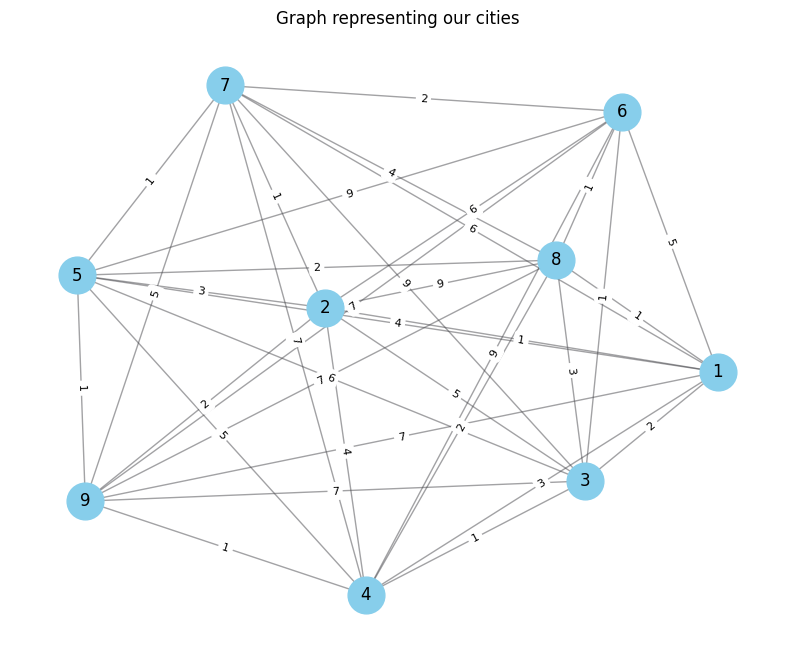

In [14]:
plot_cities(G, pos)

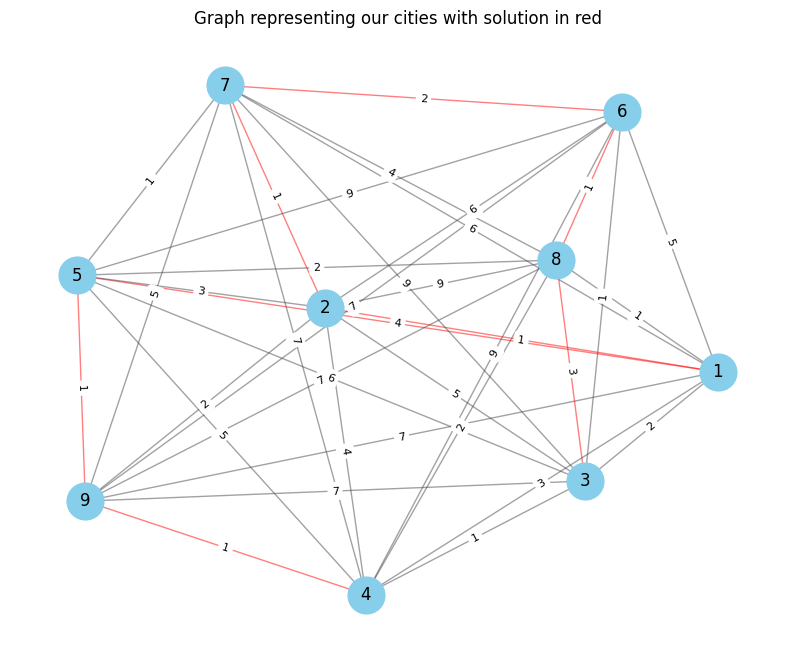

La solution est [4, 9, 5, 1, 2, 7, 6, 8, 3, 4]
Le cout total de la solution vaut : 15


In [15]:
plot_cities(G, pos, sol)